Saving 512177035_70afc925c8.jpg to 512177035_70afc925c8.jpg


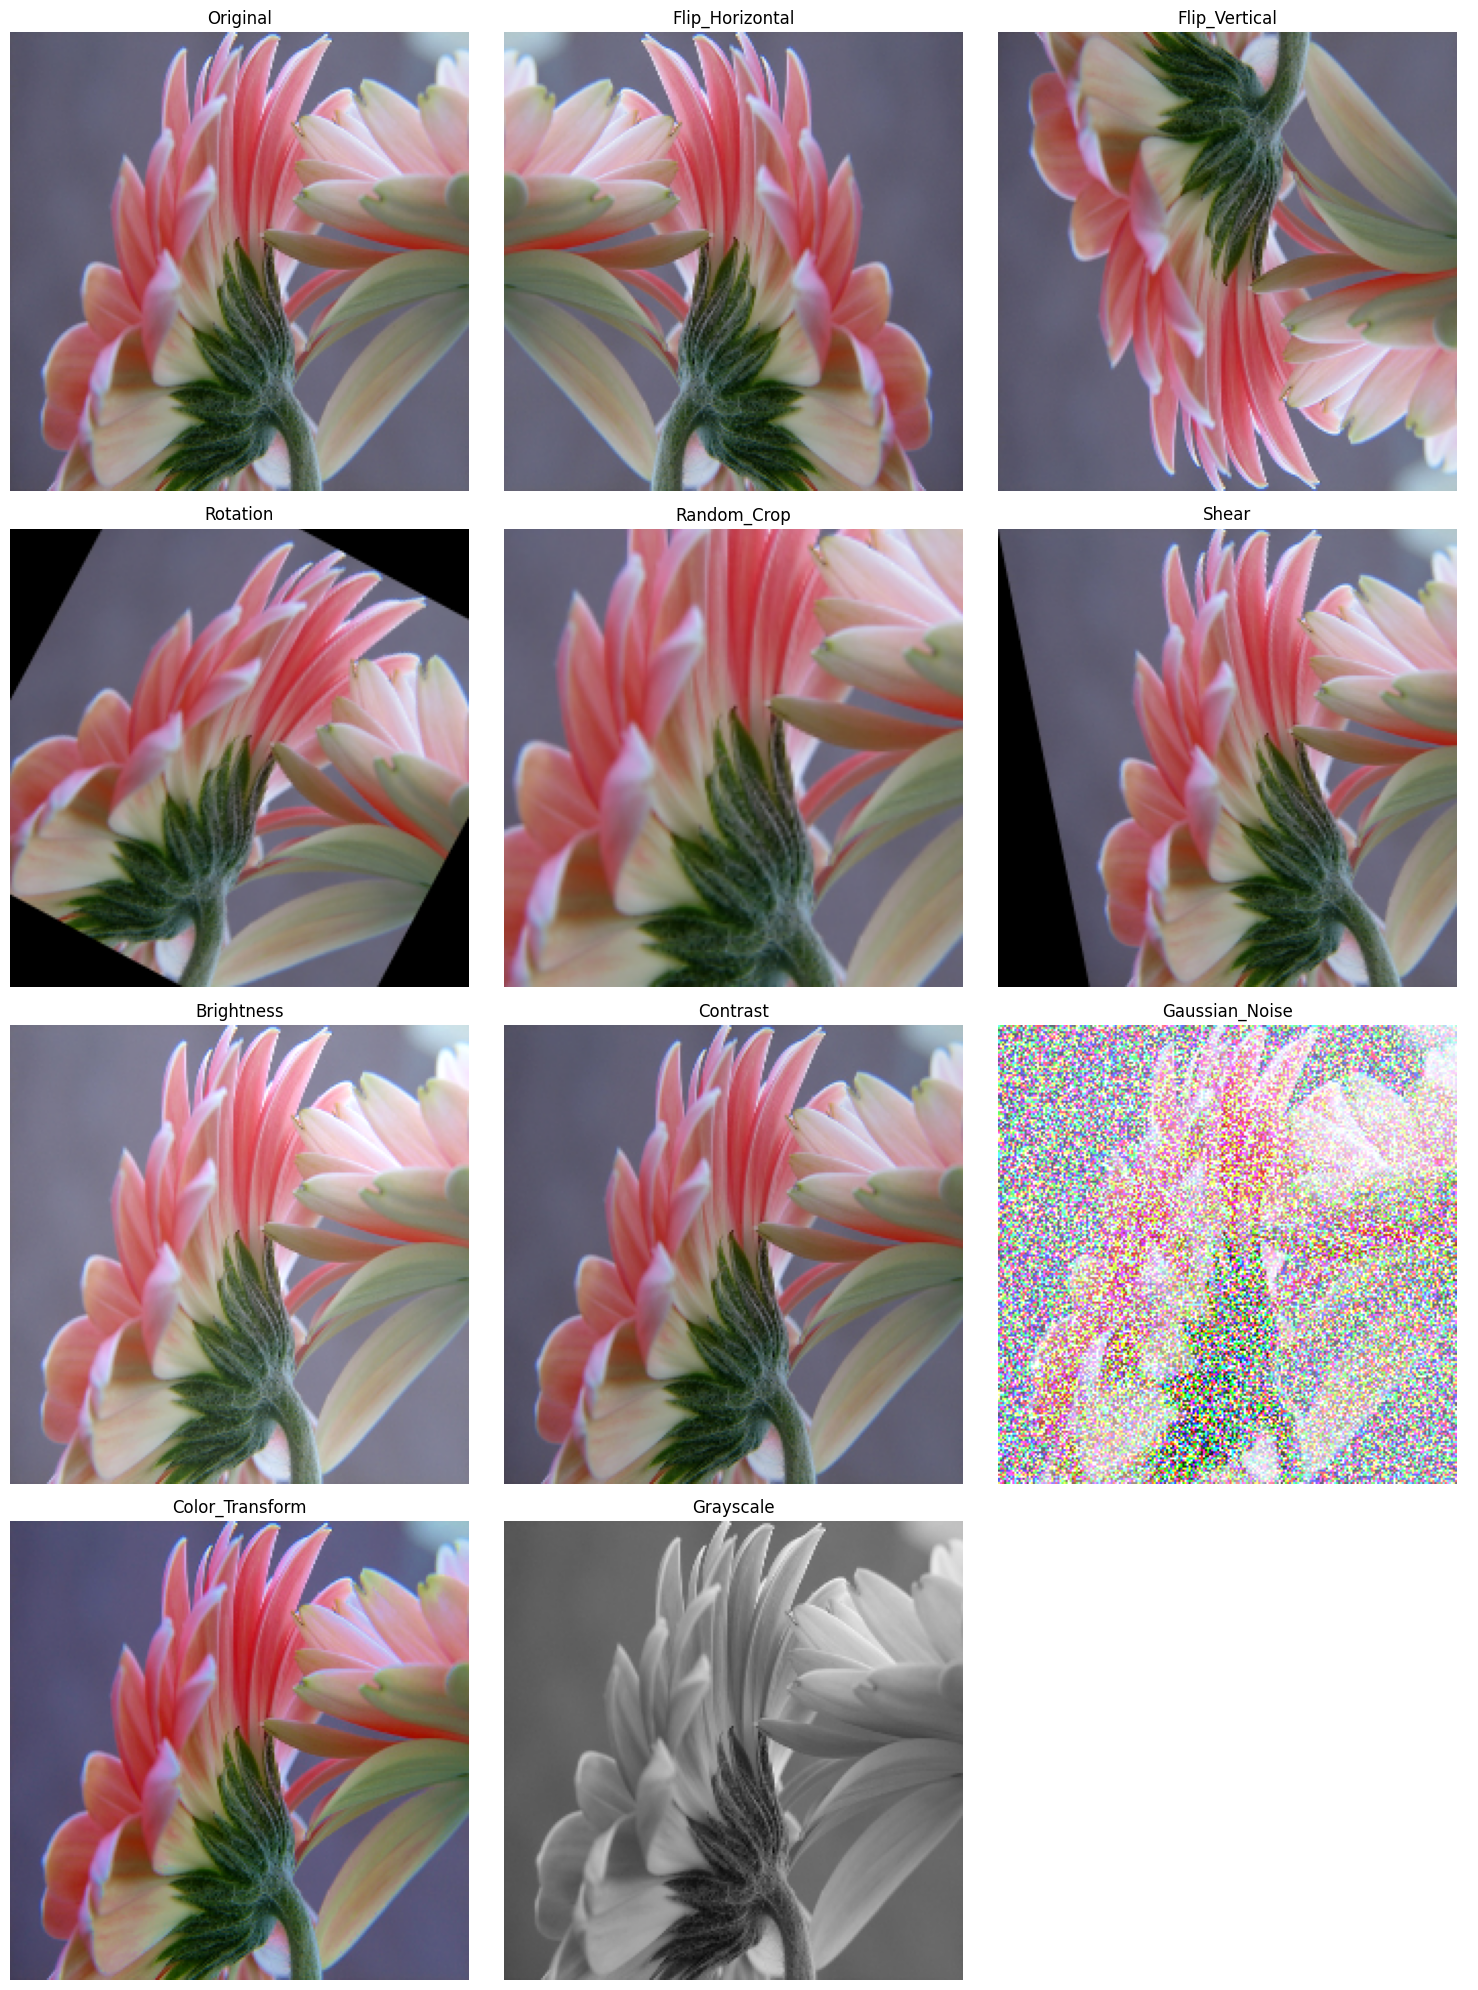

✅ Augmentation complete!
📁 Images saved at: /content/augmented_images


In [ ]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# =========================
# 2. UPLOAD IMAGES
# =========================
uploaded = files.upload()

# =========================
# 3. OUTPUT DIRECTORY
# =========================
output_dir = "/content/augmented_images"
os.makedirs(output_dir, exist_ok=True)

# =========================
# 4. PREPROCESS FUNCTION
# =========================
def preprocess_image(image):
    if image is None:
        return None
    return cv2.resize(image, (224, 224))

# =========================
# 5. AUGMENTATION FUNCTION
# =========================
def augment_image(image):
    h, w = image.shape[:2]
    augmented = []

    # Flip
    augmented.append((cv2.flip(image, 1), "Flip_Horizontal"))
    augmented.append((cv2.flip(image, 0), "Flip_Vertical"))

    # Rotation
    angle = np.random.uniform(-30, 30)
    M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1)
    rotated = cv2.warpAffine(image, M, (w, h))
    augmented.append((rotated, "Rotation"))

    # Random Crop
    crop_size = 160
    x = np.random.randint(0, w - crop_size)
    y = np.random.randint(0, h - crop_size)
    cropped = image[y:y+crop_size, x:x+crop_size]
    cropped = cv2.resize(cropped, (w, h))
    augmented.append((cropped, "Random_Crop"))

    # Shear
    M_shear = np.float32([[1, 0.2, 0], [0, 1, 0]])
    sheared = cv2.warpAffine(image, M_shear, (w, h))
    augmented.append((sheared, "Shear"))

    # Brightness
    bright = cv2.convertScaleAbs(image, alpha=1, beta=np.random.randint(-50, 50))
    augmented.append((bright, "Brightness"))

    # Contrast
    contrast = cv2.convertScaleAbs(image, alpha=np.random.uniform(0.5, 1.5), beta=0)
    augmented.append((contrast, "Contrast"))

    # Gaussian Noise
    noise = np.random.normal(0, 15, image.shape).astype(np.uint8)
    noisy = cv2.add(image, noise)
    augmented.append((noisy, "Gaussian_Noise"))

    # Color Transform (HSV)
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    hsv[:, :, 1] = cv2.add(hsv[:, :, 1], 30)
    color_aug = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)
    augmented.append((color_aug, "Color_Transform"))

    # Grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)  # keep 3 channels
    augmented.append((gray, "Grayscale"))

    return augmented



# =========================
# 6. LOAD + AUGMENT IMAGES
# =========================
processed_images = []

for filename, content in uploaded.items():
    nparr = np.frombuffer(content, np.uint8)
    image = cv2.imdecode(nparr, cv2.IMREAD_COLOR)

    if image is not None:
        base_img = preprocess_image(image)
        processed_images.append((base_img, "Original"))

        augmented_imgs = augment_image(base_img)
        processed_images.extend(augmented_imgs)

# =========================
# 7. DISPLAY IMAGES WITH LABELS
# =========================
def show_images(images, cols=3):
    rows = int(np.ceil(len(images) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    axes = axes.flatten()

    for i, ax in enumerate(axes):
        if i < len(images):
            img, label = images[i]

            if img.ndim == 2:
                img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
            else:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            ax.imshow(img)
            ax.set_title(label)
            ax.axis("off")
        else:
            ax.axis("off")

    plt.tight_layout()
    plt.show()

# SHOW FIRST 12 IMAGES
show_images(processed_images[:12])

# =========================
# 8. SAVE AUGMENTED IMAGES
# =========================
for i, (img, label) in enumerate(processed_images):
    if img.ndim == 2:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

    filename = f"{label}_{i}.jpg"
    cv2.imwrite(os.path.join(output_dir, filename), img)

print("✅ Augmentation complete!")
print(f"📁 Images saved at: {output_dir}")